<a href="https://colab.research.google.com/github/Niamh3521/SatelliteDataAI-UOA/blob/main/Geog761Lab2Q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
# Install libs if needed, note the --quiet option means a lot less annoying info than as Lab 1 when we did the same!
!pip install geemap --quiet
!pip install matplotlib-scalebar

In [3]:
# Set up GEE API
import ee
ee.Authenticate()
ee.Initialize(project='geog761-project') #<- Remember to change this to your own project's name!

In [4]:
# Import other libs
import geemap
import geopandas as gpd
import pandas as pd

In [5]:
# Define area of interest (e.g., Wellington, NZ)
aoi = ee.Geometry.Rectangle([174.6, -41.4, 174.9, -41.2])
Map = geemap.Map(center=[-41.3, 174.75], zoom=10)
Map.addLayer(aoi, {}, 'AOI')

# Visualize on the map to check got it right... (always a good idea)
Map

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [44]:
def mask_s2_clouds(image):
  qa = image.select('QA60')

  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloud_bit_mask = 1 << 10
  cirrus_bit_mask = 1 << 11
  mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(
         qa.bitwiseAnd(cirrus_bit_mask).eq(0))
  return image.updateMask(mask).divide(10000).select(['B2', 'B3', 'B4', 'B8'])

  #define the target years
years = [2018, 2020, 2022, 2024]

s2_annual= {}

# create a loop for the years to build a clean collection with selected bands for all three years
for year in years:
    s2_annual[year]= (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
        .map(mask_s2_clouds)
        .median()
        .clip(aoi))


In [45]:
# Set up visualization parameters
rgb_vis = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}

# Create a separate map object for each year
maps = {}

for year in [2018, 2020, 2022, 2024]:
    # Initialize a fresh map for this year
    m = geemap.Map(center=[-41.3, 174.75], zoom=11)

    # Add layers
    m.addLayer(s2_annual[year], rgb_vis, f'S2 {year} RGB')
    m.addLayer(aoi, {'color': 'red'}, 'AOI')

    # Store map in dictionary
    maps[year] = m

# Display Map for 2018
maps[2018]

Map(center=[-41.3, 174.75], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [46]:
# Define valid WorldCover classes (10 to 100, spaced by 10)
valid_classes = ee.List.sequence(10, 100, 10)

# Need to change this to sequential list to avoid the algs thiniing there are 99 classes rather than 9
remap_to = ee.List.sequence(1, 10)

# Load landcover map
landcover = ee.Image('ESA/WorldCover/v100/2020').select('Map').clip(aoi)

# Remap labels: create a new band with remapped values (10 → 1, ..., 100 → 10)
landcover_remapped = landcover.remap(valid_classes, remap_to).rename('Map_remapped')

In [47]:
bands = ['B2', 'B3', 'B4', 'B8']

# Dictionaries to hold training data and individual samples per year
training_data_annual = {}
samples_annual = {}

In [48]:
for year, img in s2_annual.items():
    # 1. Add remapped landcover as a band to this year's Sentinel-2 composite
    training_data_annual[year] = img.addBands(landcover_remapped)

    # 2. Extract 5,000 samples for this specific year
    samples_annual[year] = training_data_annual[year].select(bands + ['Map_remapped']).sample(
        region=aoi,
        scale=10,
        numPixels=5000,
        seed=2,
        geometries=True
    )

In [49]:
# Dictionaries to store train, validation, and test splits for each year
train_annual = {}
valid_annual = {}
test_annual = {}

for year, sample in samples_annual.items():
    # 1. Add random column to this year's sample collection
    sample_with_random = sample.randomColumn('random', seed=42)

    # 2. Split into Train (70%), Validation (20%), and Test (10%)
    train_annual[year] = sample_with_random.filter(ee.Filter.lt('random', 0.7))
    valid_annual[year] = sample_with_random.filter(
        ee.Filter.And(ee.Filter.gte('random', 0.7), ee.Filter.lt('random', 0.9))
    )
    test_annual[year] = sample_with_random.filter(ee.Filter.gte('random', 0.9))

In [50]:
# Train a Random Forest model for each year separately
classifiers_annual = {}

for year in years:
    # ee.Classifier.smileRandomForest(numberOfTrees=100) initializes the Random Forest
    # classifier with 100 decision trees using the SMILE algorithms and trains it
    # on that specific year's training split.
    classifiers_annual[year] = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
        features=train_annual[year],      # Use that year's training data split
        classProperty='Map_remapped',      # Attribute containing target class labels
        inputProperties=bands              # Sentinel-2 bands as predictor variables
    )

In [51]:
# Classify each annual Sentinel-2 image using its matching trained classifier
classified_annual = {}

for year in years:
    # .classify() applies the trained machine learning model to the annual image
    classified_annual[year] = s2_annual[year].select(bands).classify(classifiers_annual[year])

In [52]:
# Palette and visual parameters for WorldCover remapped classes (1-10)
landcover_vis = {
    'min': 1,
    'max': 10,
    'palette': [
        '006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000',
        'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75'
    ]
}

# Create a separate map object for each year
maps_annual = {}

for year in years:
    # Initialize a fresh map centered on your AOI
    m = geemap.Map()
    m.centerObject(aoi, 10)

    # 1. Add True Color Sentinel-2 Imagery
    m.addLayer(s2_annual[year], {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, f'S2 RGB {year}')

    # 2. Add Classified Landcover Map (Using random visualizer as in your code, or landcover_vis palette)
    m.addLayer(classified_annual[year].randomVisualizer(), {}, f'Classified RF {year}')

    # 3. Add Reference ESA Landcover Map
    m.addLayer(landcover_remapped.randomVisualizer(), {}, 'ESA Landcover')

    # Store the map instance in the dictionary
    maps_annual[year] = m

EEException: Computation timed out.

In [53]:
# Palette and visual parameters for WorldCover remapped classes (1-10)
landcover_vis = {
    'min': 1,
    'max': 10,
    'palette': [
        '006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000',
        'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75'
    ]
}

maps_annual = {}

for year in years: # e.g. [2018, 2020, 2022, 2024]
    m = geemap.Map()
    m.centerObject(aoi, 10)

    # 1. Add True Color Sentinel-2 Imagery
    m.addLayer(s2_annual[year], {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, f'S2 RGB {year}')

    # 2. Use fixed landcover_vis instead of randomVisualizer()
    m.addLayer(classified_annual[year], landcover_vis, f'Classified RF {year}')

    # 3. Reference ESA Landcover
    m.addLayer(landcover_remapped, landcover_vis, 'ESA Landcover')

    maps_annual[year] = m

In [54]:
maps_annual[2018]

maps_annual[2022]

Map(center=[-41.300046246343555, 174.75000000000097], controls=(WidgetControl(options=['position', 'transparen…

In [57]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# 1. Target specifically the year 2020
target_year = 2020

# Validate 2020 data using 2020's trained classifier
validated_2020 = valid_annual[target_year].classify(classifiers_annual[target_year], 'predicted')

# Function to export server-side data to client-side lists
def fc_to_lists(fc, classProp, predProp):
    values = fc.aggregate_array(classProp).getInfo()
    preds = fc.aggregate_array(predProp).getInfo()
    return values, preds

# Get predicted vs actual from 2020 validation set
y_true_2020, y_pred_2020 = fc_to_lists(validated_2020, 'Map_remapped', 'predicted')

# Labels for original classes
label_map = {i + 1: valid_classes.get(i).getInfo() for i in range(10)}
label_names = [label_map[i + 1] for i in range(10)]

# Compute metrics for 2020
cm_2020 = confusion_matrix(y_true_2020, y_pred_2020, labels=list(range(1, 11)))
report_2020 = classification_report(
    y_true_2020,
    y_pred_2020,
    labels=list(range(1, 11)),
    target_names=[str(l) for l in label_names],
    zero_division=0
)

# Pretty-print 2020 results
print(f"=== CONFUSION MATRIX ({target_year}) ===")
print(pd.DataFrame(cm_2020, index=[f"Actual {l}" for l in label_names],
                            columns=[f"Pred {l}" for l in label_names]))

print(f"\n=== CLASSIFICATION REPORT ({target_year}) ===")
print(report_2020)

=== CONFUSION MATRIX (2020) ===
            Pred 10  Pred 20  Pred 30  Pred 40  Pred 50  Pred 60  Pred 70  \
Actual 10       250        0       28        0        3        0        0   
Actual 20         1        0        0        0        0        0        0   
Actual 30        36        0      146        0        4        0        0   
Actual 40         0        0        1        0        0        0        0   
Actual 50         2        0       13        0       35        3        0   
Actual 60         0        0        1        0        3        0        0   
Actual 70         0        0        0        0        0        0        0   
Actual 80         0        0        0        0        4        0        0   
Actual 90         1        0        2        0        0        0        0   
Actual 100        0        0        0        0        0        0        0   

            Pred 80  Pred 90  Pred 100  
Actual 10         0        0         0  
Actual 20         0        0         0

In [58]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# 1. Target the 2020 TEST split specifically
target_year = 2020

# Classify the 2020 TEST set (using test_annual, NOT valid_annual)
tested_2020 = test_annual[target_year].classify(classifiers_annual[target_year], 'predicted')

# 2. Extract actual vs predicted lists
y_true_test, y_pred_test = fc_to_lists(tested_2020, 'Map_remapped', 'predicted')

# 3. Compute Overall Test Accuracy Average
overall_test_acc = accuracy_score(y_true_test, y_pred_test)

# 4. Print results
print(f"==========================================")
print(f"      2020 TEST ACCURACY: {overall_test_acc * 100:.2f}%")
print(f"==========================================")

# Detailed per-class breakdown on test data
report_test = classification_report(
    y_true_test,
    y_pred_test,
    labels=list(range(1, 11)),
    target_names=[str(l) for l in label_names],
    zero_division=0
)
print("\nTest Classification Report:")
print(report_test)

      2020 TEST ACCURACY: 90.20%

Test Classification Report:
              precision    recall  f1-score   support

          10       0.86      0.86      0.86       118
          20       0.00      0.00      0.00         0
          30       0.80      0.79      0.79        84
          40       0.00      0.00      0.00         0
          50       0.62      0.72      0.67        25
          60       0.00      0.00      0.00         3
          70       0.00      0.00      0.00         0
          80       1.00      0.99      0.99       269
          90       0.00      0.00      0.00         1
         100       0.00      0.00      0.00         0

    accuracy                           0.90       500
   macro avg       0.33      0.34      0.33       500
weighted avg       0.90      0.90      0.90       500



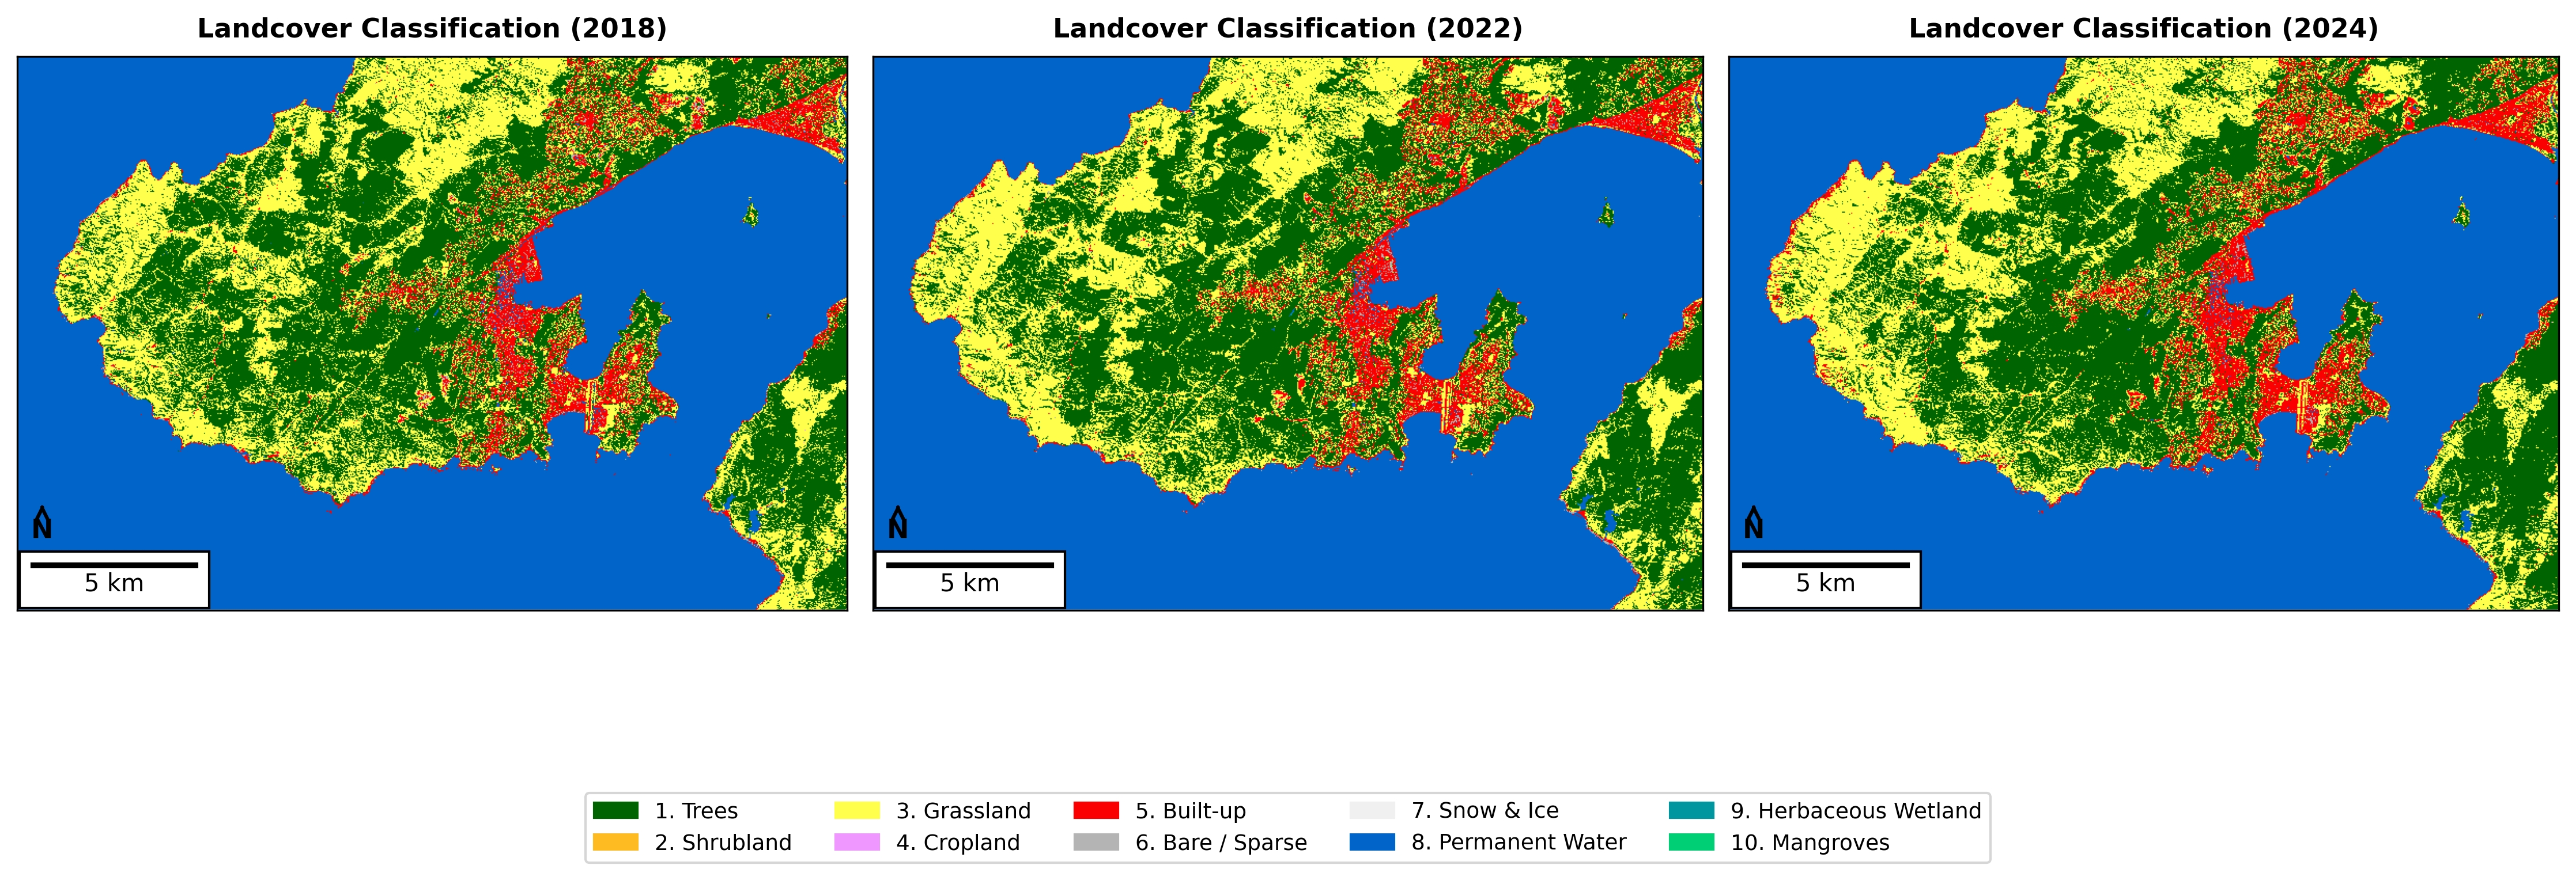

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
from PIL import Image
from io import BytesIO
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Configuration & Setup
hex_palette = [
    '006400', 'ffbb22', 'ffff4c', 'f096ff', 'fa0000',
    'b4b4b4', 'f0f0f0', '0064c8', '0096a0', '00cf75'
]
class_labels = {
    1: 'Trees', 2: 'Shrubland', 3: 'Grassland', 4: 'Cropland', 5: 'Built-up',
    6: 'Bare / Sparse', 7: 'Snow & Ice', 8: 'Permanent Water', 9: 'Herbaceous Wetland', 10: 'Mangroves'
}
vis_params = {'min': 1, 'max': 10, 'palette': hex_palette}
years = [2018, 2022, 2024]


# Dynamic spatial scale calculation
bounds = aoi.bounds()
coords = bounds.coordinates().get(0).getInfo()
sw, se = ee.Geometry.Point(coords[0]), ee.Geometry.Point(coords[1])
aoi_width_meters = sw.distance(se).getInfo()

thumb_dim = 800
pixel_size_meters = aoi_width_meters / thumb_dim

# Determine scale bar length (e.g., 5 km bar in pixel units)
bar_meters = 5000  # 5 kilometers
bar_pixels = bar_meters / pixel_size_meters

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

def add_north_arrow(ax, x=0.92, y=0.9, size=0.08):
    ax.annotate(
        'N', xy=(x, y), xytext=(x, y - size),
        xycoords='axes fraction', textcoords='axes fraction',
        ha='center', va='bottom', fontsize=11, fontweight='bold',
        arrowprops=dict(arrowstyle='->', facecolor='black', edgecolor='black', lw=1.5)
    )

for idx, year in enumerate(years):
    ax = axes[idx]

    url = classified_annual[year].getThumbURL({
        'region': aoi,
        'dimensions': thumb_dim,
        'format': 'png',
        **vis_params
    })

    response = requests.get(url)
    img_pil = Image.open(BytesIO(response.content))
    ax.imshow(img_pil)

    # Add North Arrow to every map panel
    add_north_arrow(ax, x=0.03, y=0.2)

    # Add Scale Bar to EVERY subplot (no 'if idx == 2:' check)
    scalebar = AnchoredSizeBar(
        ax.transData,
        bar_pixels,
        f'{bar_meters // 1000} km',
        'lower left',
        pad=0.5,
        color='black',
        frameon=True,
        size_vertical=3
    )
    ax.add_artist(scalebar)

    ax.set_title(f'Landcover Classification ({year})', fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks([])
    ax.set_yticks([])

# Shared Legend Setup
legend_patches = [
    mpatches.Patch(color=f'#{hex_palette[i]}', label=f"{i+1}. {class_labels[i+1]}")
    for i in range(10)
]

fig.legend(
    handles=legend_patches,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    frameon=True,
    facecolor='#ffffff',
    edgecolor='#cccccc',
    fontsize=9
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)

plt.savefig('classified_multiyear_publication_all_scales.png', dpi=300, bbox_inches='tight')
plt.show()

